**RQ1_Dietary_habits**

In [57]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ1_dietary_habits_by_obesity_group.csv


,Obesity_Group,sample_size,avg_vegetable_consumption_FCVC,avg_meals_per_day_NCP,high_calorie_food_yes_percent
0,Underweight,267,2.475,2.943,81.273
1,Normal,282,2.337,2.748,72.340
2,Overweight,566,2.269,2.537,83.039
3,Obese,972,2.520,2.717,98.045


Saved figure: /kaggle/working/figures/RQ1_dietary_habits_by_obesity_group.pdf


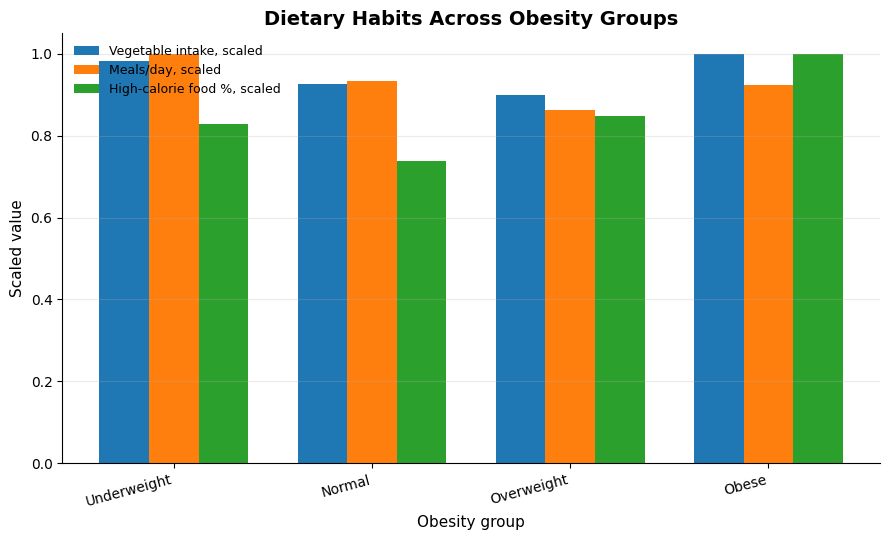


ANSWER TO RQ1
The group with the highest percentage of frequent high-calorie food consumption is: Obese.
The group with the highest average vegetable consumption is: Obese.
Overall, the table and figure show how dietary behavior varies across obesity classifications.


In [58]:

# RQ1: Dietary habits and obesity classification
# Variables: FAVC, FCVC, NCP, CAEC, NObeyesdad

summary = (
    df.groupby('Obesity_Group', observed=False)
      .agg(
          sample_size=('NObeyesdad', 'size'),
          avg_vegetable_consumption_FCVC=('FCVC', 'mean'),
          avg_meals_per_day_NCP=('NCP', 'mean'),
          high_calorie_food_yes_percent=('FAVC', percent_yes)
      )
      .reset_index()
)
summary = summary.round(3)
save_table(summary, 'RQ1_dietary_habits_by_obesity_group.csv')
display(summary)

# Figure: normalized grouped bar chart for comparison across different units
plot_df = summary.copy()
for col in ['avg_vegetable_consumption_FCVC', 'avg_meals_per_day_NCP', 'high_calorie_food_yes_percent']:
    max_val = plot_df[col].max()
    plot_df[col + '_scaled'] = plot_df[col] / max_val if max_val != 0 else plot_df[col]

x = np.arange(len(plot_df))
width = 0.25
plt.figure(figsize=(9, 5.5))
plt.bar(x - width, plot_df['avg_vegetable_consumption_FCVC_scaled'], width, label='Vegetable intake, scaled')
plt.bar(x, plot_df['avg_meals_per_day_NCP_scaled'], width, label='Meals/day, scaled')
plt.bar(x + width, plot_df['high_calorie_food_yes_percent_scaled'], width, label='High-calorie food %, scaled')
plt.xticks(x, plot_df['Obesity_Group'].astype(str), rotation=15, ha='right')
style_plot('Dietary Habits Across Obesity Groups', 'Obesity group', 'Scaled value')
plt.legend(frameon=False, fontsize=9)
save_figure('RQ1_dietary_habits_by_obesity_group.pdf')

# Actual answer
highest_favc = summary.loc[summary['high_calorie_food_yes_percent'].idxmax(), 'Obesity_Group']
highest_fcvc = summary.loc[summary['avg_vegetable_consumption_FCVC'].idxmax(), 'Obesity_Group']
print('\nANSWER TO RQ1')
print(f"The group with the highest percentage of frequent high-calorie food consumption is: {highest_favc}.")
print(f"The group with the highest average vegetable consumption is: {highest_fcvc}.")
print('Overall, the table and figure show how dietary behavior varies across obesity classifications.')


**RQ2_Activity_Screen_Time**

In [59]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ2_activity_screen_time_by_obesity_group.csv
Saved table: /kaggle/working/tables/RQ2_activity_screen_time_correlations.csv


,Obesity_Group,sample_size,avg_physical_activity_FAF,avg_screen_time_TUE,avg_obesity_score
0,Underweight,267,1.274,0.848,0.000
1,Normal,282,1.252,0.677,1.000
2,Overweight,566,1.008,0.671,2.512
3,Obese,972,0.875,0.603,4.972


,relationship,pearson_r,p_value
0,FAF vs obesity score,-0.20600,0.0
1,TUE vs obesity score,-0.11532,0.0


Saved figure: /kaggle/working/figures/RQ2_activity_screen_time_scatter.pdf


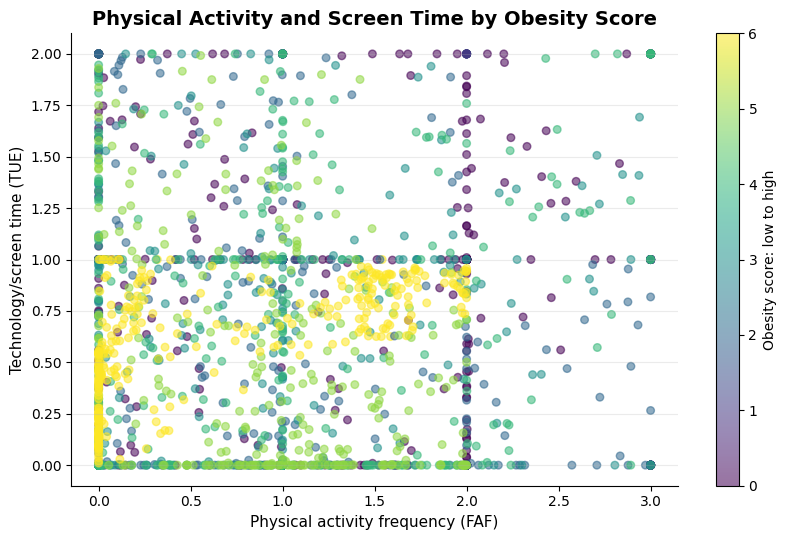


ANSWER TO RQ2
Correlation between physical activity and obesity score: r=-0.206, p=1.955e-21.
Correlation between screen time and obesity score: r=-0.115, p=1.272e-07.
Negative r suggests lower obesity scores with higher activity; positive r suggests higher obesity scores with higher screen time.


In [60]:

# RQ2: Physical activity, screen time, and obesity level
# Variables: FAF, TUE, NObeyesdad

summary = (
    df.groupby('Obesity_Group', observed=False)
      .agg(sample_size=('NObeyesdad', 'size'), avg_physical_activity_FAF=('FAF', 'mean'), avg_screen_time_TUE=('TUE', 'mean'), avg_obesity_score=('Obesity_Score', 'mean'))
      .reset_index()
      .round(3)
)

pearson_faf = pearsonr(df['FAF'], df['Obesity_Score'])
pearson_tue = pearsonr(df['TUE'], df['Obesity_Score'])
corr_table = pd.DataFrame({
    'relationship': ['FAF vs obesity score', 'TUE vs obesity score'],
    'pearson_r': [pearson_faf.statistic, pearson_tue.statistic],
    'p_value': [pearson_faf.pvalue, pearson_tue.pvalue]
}).round(5)

final_table = summary.merge(pd.DataFrame({'key':[1]}), how='cross').drop(columns='key')
save_table(summary, 'RQ2_activity_screen_time_by_obesity_group.csv')
save_table(corr_table, 'RQ2_activity_screen_time_correlations.csv')
display(summary)
display(corr_table)

# Figure: scatter plot with obesity score color mapping
plt.figure(figsize=(8.5, 5.5))
scatter = plt.scatter(df['FAF'], df['TUE'], c=df['Obesity_Score'], alpha=0.55, s=30)
cb = plt.colorbar(scatter)
cb.set_label('Obesity score: low to high')
style_plot('Physical Activity and Screen Time by Obesity Score', 'Physical activity frequency (FAF)', 'Technology/screen time (TUE)')
save_figure('RQ2_activity_screen_time_scatter.pdf')

print('\nANSWER TO RQ2')
print(f"Correlation between physical activity and obesity score: r={pearson_faf.statistic:.3f}, p={pearson_faf.pvalue:.4g}.")
print(f"Correlation between screen time and obesity score: r={pearson_tue.statistic:.3f}, p={pearson_tue.pvalue:.4g}.")
print('Negative r suggests lower obesity scores with higher activity; positive r suggests higher obesity scores with higher screen time.')


**RQ3_Demographics**

In [61]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ3_obesity_distribution_by_age_gender.csv


Obesity_Group,Age_Group,Gender,Underweight,Normal,Overweight,Obese,sample_size
0,18-25,Female,23.94,17.33,21.59,37.15,681
1,18-25,Male,14.76,19.28,32.83,33.13,664
2,26-35,Female,1.98,5.53,23.32,69.17,253
3,26-35,Male,0.00,4.67,25.23,70.09,321
4,36-45,Female,1.04,3.12,42.71,53.12,96
5,36-45,Male,0.00,3.45,17.24,79.31,58
6,46+,Female,0.00,40.00,20.00,40.00,5
7,46+,Male,0.00,0.00,100.00,0.00,9


Saved figure: /kaggle/working/figures/RQ3_obesity_by_age_gender.pdf


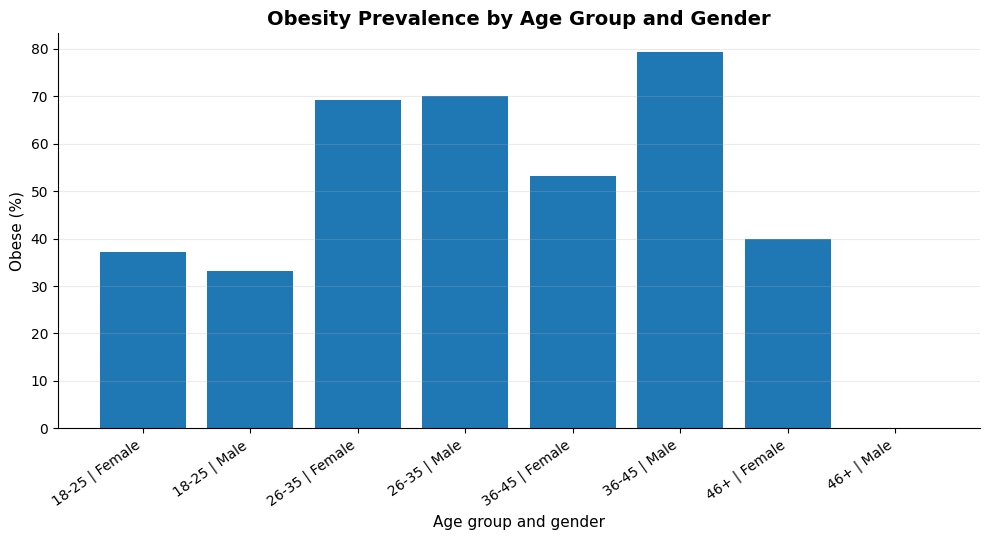

Saved table: /kaggle/working/tables/RQ3_demographic_chi_square_tests.csv


,test,chi_square,p_value
0,Age group vs obesity group,323.62412,0.0
1,Gender vs obesity group,27.73059,0.0



ANSWER TO RQ3
The highest obese percentage appears in: 36-45 | Male (79.31%).
Age group association test p-value: 2.519e-64; gender association test p-value: 4.137e-06.
These results quantify whether obesity outcomes differ across demographic segments.


In [62]:

# RQ3: Age, gender, and obesity outcomes
# Variables: Age, Gender, NObeyesdad

bins = [0, 25, 35, 45, np.inf]
labels = ['18-25', '26-35', '36-45', '46+']
df_rq = df.copy()
df_rq['Age_Group'] = pd.cut(df_rq['Age'], bins=bins, labels=labels, right=True)

counts = pd.crosstab([df_rq['Age_Group'], df_rq['Gender']], df_rq['Obesity_Group'])
perc = counts.div(counts.sum(axis=1), axis=0).mul(100).reset_index().round(2)
perc['sample_size'] = counts.sum(axis=1).values
save_table(perc, 'RQ3_obesity_distribution_by_age_gender.csv')
display(perc)

# Figure: obese percentage by age group and gender
fig_df = perc[['Age_Group', 'Gender', 'Obese', 'sample_size']].copy()
fig_df['label'] = fig_df['Age_Group'].astype(str) + ' | ' + fig_df['Gender'].astype(str)
plt.figure(figsize=(10, 5.5))
plt.bar(fig_df['label'], fig_df['Obese'])
plt.xticks(rotation=35, ha='right')
style_plot('Obesity Prevalence by Age Group and Gender', 'Age group and gender', 'Obese (%)')
save_figure('RQ3_obesity_by_age_gender.pdf')

# Chi-square test for demographics vs obesity group
age_chi = chi2_contingency(pd.crosstab(df_rq['Age_Group'], df_rq['Obesity_Group']))
gender_chi = chi2_contingency(pd.crosstab(df_rq['Gender'], df_rq['Obesity_Group']))
test_table = pd.DataFrame({
    'test': ['Age group vs obesity group', 'Gender vs obesity group'],
    'chi_square': [age_chi.statistic, gender_chi.statistic],
    'p_value': [age_chi.pvalue, gender_chi.pvalue]
}).round(5)
save_table(test_table, 'RQ3_demographic_chi_square_tests.csv')
display(test_table)

print('\nANSWER TO RQ3')
max_row = fig_df.loc[fig_df['Obese'].idxmax()]
print(f"The highest obese percentage appears in: {max_row['label']} ({max_row['Obese']:.2f}%).")
print(f"Age group association test p-value: {age_chi.pvalue:.4g}; gender association test p-value: {gender_chi.pvalue:.4g}.")
print('These results quantify whether obesity outcomes differ across demographic segments.')


**RQ4_Lifestyle_Risks**

In [63]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ4_smoking_alcohol_obesity_distribution.csv


Obesity_Group,risk_factor,group,Underweight,Normal,Overweight,Obese,sample_size
0,SMOKE,no,13.02,13.17,27.31,46.50,2043
1,SMOKE,yes,2.27,29.55,18.18,50.00,44
2,CALC,Always,0.00,100.00,0.00,0.00,1
3,CALC,Frequently,1.43,25.71,50.00,22.86,70
4,CALC,Sometimes,10.80,11.52,25.58,52.10,1380
5,CALC,no,18.40,16.35,27.99,37.26,636


Saved table: /kaggle/working/tables/RQ4_lifestyle_chi_square_tests.csv


,relationship,chi_square,p_value
0,SMOKE vs obesity group,13.87730,0.00308
1,CALC vs obesity group,93.16644,0.00000


Saved figure: /kaggle/working/figures/RQ4_smoking_alcohol_obesity.pdf


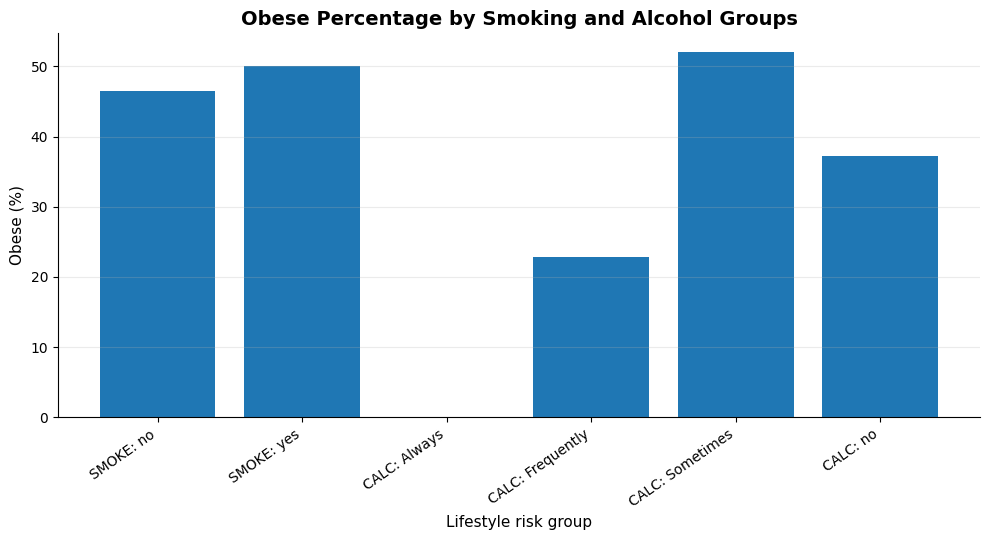


ANSWER TO RQ4
The lifestyle category with the highest obese percentage is: CALC: Sometimes (52.10%).
SMOKE association p-value: 0.003077; CALC association p-value: 3.762e-16.
The table and chi-square tests show whether smoking and alcohol categories are statistically associated with obesity classification.


In [64]:

# RQ4: Smoking, alcohol consumption, and obesity classification
# Variables: SMOKE, CALC, NObeyesdad

def distribution_table(variable):
    ct = pd.crosstab(df[variable], df['Obesity_Group'])
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100).reset_index().round(2)
    pct.insert(0, 'risk_factor', variable)
    pct = pct.rename(columns={variable: 'group'})
    pct['sample_size'] = ct.sum(axis=1).values
    return pct

smoke_tbl = distribution_table('SMOKE')
alcohol_tbl = distribution_table('CALC')
summary = pd.concat([smoke_tbl, alcohol_tbl], ignore_index=True)
save_table(summary, 'RQ4_smoking_alcohol_obesity_distribution.csv')
display(summary)

smoke_chi = chi2_contingency(pd.crosstab(df['SMOKE'], df['Obesity_Group']))
alcohol_chi = chi2_contingency(pd.crosstab(df['CALC'], df['Obesity_Group']))
tests = pd.DataFrame({
    'relationship': ['SMOKE vs obesity group', 'CALC vs obesity group'],
    'chi_square': [smoke_chi.statistic, alcohol_chi.statistic],
    'p_value': [smoke_chi.pvalue, alcohol_chi.pvalue]
}).round(5)
save_table(tests, 'RQ4_lifestyle_chi_square_tests.csv')
display(tests)

# Figure: obese percentage by smoking/alcohol group
fig_df = summary[['risk_factor', 'group', 'Obese', 'sample_size']].copy()
fig_df['label'] = fig_df['risk_factor'] + ': ' + fig_df['group'].astype(str)
plt.figure(figsize=(10, 5.5))
plt.bar(fig_df['label'], fig_df['Obese'])
plt.xticks(rotation=35, ha='right')
style_plot('Obese Percentage by Smoking and Alcohol Groups', 'Lifestyle risk group', 'Obese (%)')
save_figure('RQ4_smoking_alcohol_obesity.pdf')

print('\nANSWER TO RQ4')
max_row = fig_df.loc[fig_df['Obese'].idxmax()]
print(f"The lifestyle category with the highest obese percentage is: {max_row['label']} ({max_row['Obese']:.2f}%).")
print(f"SMOKE association p-value: {smoke_chi.pvalue:.4g}; CALC association p-value: {alcohol_chi.pvalue:.4g}.")
print('The table and chi-square tests show whether smoking and alcohol categories are statistically associated with obesity classification.')


**RQ5_Feature_Importance**

In [65]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ5_feature_importance_full.csv


,rank,feature,importance_score
0,1,num__Weight,0.27652
1,2,num__Age,0.09139
2,3,num__Height,0.08277
3,4,num__FCVC,0.07508
4,5,num__NCP,0.05085
5,6,num__TUE,0.04792
6,7,num__FAF,0.04708
7,8,num__CH2O,0.04501
8,9,cat__Gender_Female,0.03664
9,10,cat__Gender_Male,0.03603


Saved table: /kaggle/working/tables/RQ5_random_forest_predictor_model_performance.csv


,model,accuracy,macro_f1
0,Random Forest,0.9378,0.93697


Saved figure: /kaggle/working/figures/RQ5_top_feature_importance.pdf


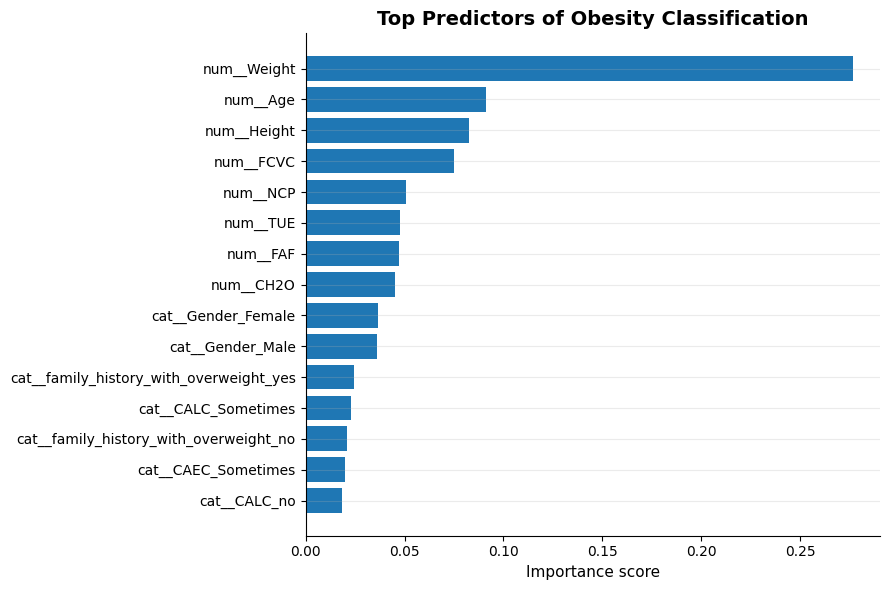


ANSWER TO RQ5
The strongest predictor is: num__Weight with importance 0.2765.
Random Forest test accuracy: 0.938; macro-F1: 0.937.
The feature-importance ranking identifies the behavioral and demographic variables with the greatest predictive contribution.


In [66]:

# RQ5: Best predictors of obesity classification
# Variables: all predictors except NObeyesdad

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

X = df.drop(columns=['NObeyesdad', 'Obesity_Group', 'Obesity_Score'])
y = df['NObeyesdad']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

model = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# Get feature names after one-hot encoding
feature_names = pipe.named_steps['preprocess'].get_feature_names_out()
importances = pipe.named_steps['model'].feature_importances_
importance_table = (
    pd.DataFrame({'feature': feature_names, 'importance_score': importances})
      .sort_values('importance_score', ascending=False)
      .reset_index(drop=True)
)
importance_table.insert(0, 'rank', np.arange(1, len(importance_table)+1))
importance_table = importance_table.round(5)
save_table(importance_table, 'RQ5_feature_importance_full.csv')
display(importance_table.head(15))

performance = pd.DataFrame({
    'model': ['Random Forest'],
    'accuracy': [accuracy_score(y_test, y_pred)],
    'macro_f1': [f1_score(y_test, y_pred, average='macro')]
}).round(5)
save_table(performance, 'RQ5_random_forest_predictor_model_performance.csv')
display(performance)

# Figure: top 15 features
fig_df = importance_table.head(15).sort_values('importance_score', ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(fig_df['feature'], fig_df['importance_score'])
style_plot('Top Predictors of Obesity Classification', 'Importance score', None)
save_figure('RQ5_top_feature_importance.pdf')

print('\nANSWER TO RQ5')
print(f"The strongest predictor is: {importance_table.loc[0, 'feature']} with importance {importance_table.loc[0, 'importance_score']:.4f}.")
print(f"Random Forest test accuracy: {performance.loc[0, 'accuracy']:.3f}; macro-F1: {performance.loc[0, 'macro_f1']:.3f}.")
print('The feature-importance ranking identifies the behavioral and demographic variables with the greatest predictive contribution.')


**RQ6_Water_Intake**

In [67]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ6_water_intake_obesity_distribution.csv


,Water_Intake_Level,Underweight,Normal,Overweight,Obese,sample_size,avg_CH2O,avg_obesity_score
0,Low,16.74,16.74,22.38,44.14,478,1.128,2.906
1,Medium,12.74,14.63,30.71,41.92,1107,2.016,2.971
2,High,9.16,7.97,23.71,59.16,502,2.816,3.703


Saved table: /kaggle/working/tables/RQ6_water_intake_anova.csv


,test,f_statistic,p_value
0,ANOVA: obesity score by water intake level,28.21906,0.0


Saved figure: /kaggle/working/figures/RQ6_water_intake_obesity_line.pdf


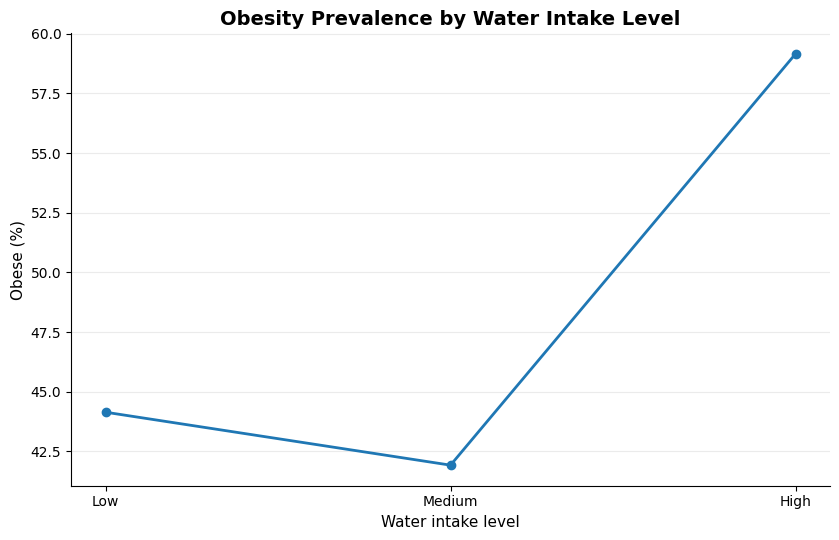


ANSWER TO RQ6
Lowest obese percentage: Medium water intake (41.92%).
Highest obese percentage: High water intake (59.16%).
ANOVA p-value: 8.084e-13.
The table and line chart show whether obesity prevalence changes across water-consumption levels.


In [68]:

# RQ6: Water consumption and obesity levels
# Variables: CH2O, NObeyesdad

df_rq = df.copy()
df_rq['Water_Intake_Level'] = pd.cut(df_rq['CH2O'], bins=[0, 1.5, 2.5, np.inf], labels=['Low', 'Medium', 'High'], include_lowest=True)

ct = pd.crosstab(df_rq['Water_Intake_Level'], df_rq['Obesity_Group'])
pct = ct.div(ct.sum(axis=1), axis=0).mul(100).reset_index().round(2)
pct['sample_size'] = ct.sum(axis=1).values
avg = df_rq.groupby('Water_Intake_Level', observed=False).agg(avg_CH2O=('CH2O', 'mean'), avg_obesity_score=('Obesity_Score', 'mean')).reset_index().round(3)
summary = pct.merge(avg, on='Water_Intake_Level')
save_table(summary, 'RQ6_water_intake_obesity_distribution.csv')
display(summary)

# ANOVA across water intake groups
samples = [g['Obesity_Score'].dropna().values for _, g in df_rq.groupby('Water_Intake_Level', observed=False)]
anova = f_oneway(*samples)
test_table = pd.DataFrame({'test':['ANOVA: obesity score by water intake level'], 'f_statistic':[anova.statistic], 'p_value':[anova.pvalue]}).round(5)
save_table(test_table, 'RQ6_water_intake_anova.csv')
display(test_table)

# Figure: line chart of obese percentage by water intake
fig_df = summary.copy()
plt.figure(figsize=(8.5, 5.5))
plt.plot(fig_df['Water_Intake_Level'].astype(str), fig_df['Obese'], marker='o', linewidth=2)
style_plot('Obesity Prevalence by Water Intake Level', 'Water intake level', 'Obese (%)')
save_figure('RQ6_water_intake_obesity_line.pdf')

print('\nANSWER TO RQ6')
min_row = fig_df.loc[fig_df['Obese'].idxmin()]
max_row = fig_df.loc[fig_df['Obese'].idxmax()]
print(f"Lowest obese percentage: {min_row['Water_Intake_Level']} water intake ({min_row['Obese']:.2f}%).")
print(f"Highest obese percentage: {max_row['Water_Intake_Level']} water intake ({max_row['Obese']:.2f}%).")
print(f"ANOVA p-value: {anova.pvalue:.4g}.")
print('The table and line chart show whether obesity prevalence changes across water-consumption levels.')


**RQ7_Model_Performance**

In [69]:

# ============================================================
# Kaggle-ready setup: load raw obesity dataset and shared helpers
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway

# Kaggle output directory
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Change this only if needed. On Kaggle, the dataset usually lives under /kaggle/input/...
DATASET_PATH = None


def find_dataset_file():
    """Find the obesity dataset on Kaggle or locally. Supports CSV and Excel."""
    if DATASET_PATH:
        return DATASET_PATH
    patterns = [
        '/kaggle/input/**/*.csv', '/kaggle/input/**/*.xlsx', '/kaggle/input/**/*.xls',
        './*.csv', './*.xlsx', './*.xls',
        '../input/**/*.csv', '../input/**/*.xlsx', '../input/**/*.xls'
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    # Prefer files whose name looks like the obesity dataset
    ranked = sorted(candidates, key=lambda p: ('obesity' not in os.path.basename(p).lower(), len(p)))
    if not ranked:
        raise FileNotFoundError('No CSV/XLSX dataset file found. Upload the raw dataset to Kaggle Input or set DATASET_PATH manually.')
    return ranked[0]


def load_dataset():
    path = find_dataset_file()
    print(f'Loading dataset from: {path}')
    if path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


def clean_dataset(df):
    """Basic cleaning only; avoids changing the research meaning of variables."""
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    # Normalize object columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    return df


def add_obesity_group(df):
    """Collapse detailed target classes into paper-friendly groups."""
    df = df.copy()
    mapping = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obese',
        'Obesity_Type_II': 'Obese',
        'Obesity_Type_III': 'Obese'
    }
    df['Obesity_Group'] = df['NObeyesdad'].map(mapping).fillna(df['NObeyesdad'])
    order = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df['Obesity_Group'] = pd.Categorical(df['Obesity_Group'], categories=order, ordered=True)
    return df


def add_obesity_score(df):
    """Ordinal score for correlation/ANOVA summaries."""
    df = df.copy()
    score_map = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    df['Obesity_Score'] = df['NObeyesdad'].map(score_map)
    return df


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    return path


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path


def percent_yes(series):
    return (series.astype(str).str.lower().eq('yes').mean() * 100)


def style_plot(title, xlabel=None, ylabel=None):
    plt.title(title, fontsize=14, weight='bold')
    if xlabel: plt.xlabel(xlabel, fontsize=11)
    if ylabel: plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)


df = add_obesity_score(add_obesity_group(clean_dataset(load_dataset())))
display(df.head())
print(df['NObeyesdad'].value_counts())


Loading dataset from: ../input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv
Dataset shape: 2111 rows × 17 columns


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad,Obesity_Group,Obesity_Score
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight,Normal,1
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Overweight,2
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Overweight,3


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


Saved table: /kaggle/working/tables/RQ7_model_performance_comparison.csv


,model,accuracy,macro_precision,macro_recall,macro_f1
4,Gradient Boosting,0.97129,0.97044,0.97046,0.97041
3,Random Forest,0.93780,0.94219,0.93555,0.93697
2,Decision Tree,0.93301,0.93302,0.93100,0.93131
0,Logistic Regression,0.90431,0.90019,0.90250,0.90056
1,KNN,0.80383,0.79178,0.79610,0.77607


Saved table: /kaggle/working/tables/RQ7_best_model_confusion_matrix.csv


,Pred: Insufficient_Weight,Pred: Normal_Weight,Pred: Obesity_Type_I,Pred: Obesity_Type_II,Pred: Obesity_Type_III,Pred: Overweight_Level_I,Pred: Overweight_Level_II
Actual: Insufficient_Weight,53,0,0,0,0,0,0
Actual: Normal_Weight,0,54,0,0,0,1,2
Actual: Obesity_Type_I,0,0,69,0,0,1,0
Actual: Obesity_Type_II,0,0,0,60,0,0,0
Actual: Obesity_Type_III,0,0,0,1,64,0,0
Actual: Overweight_Level_I,0,2,0,0,0,51,2
Actual: Overweight_Level_II,0,0,1,0,0,2,55


Saved figure: /kaggle/working/figures/RQ7_model_performance_comparison.pdf


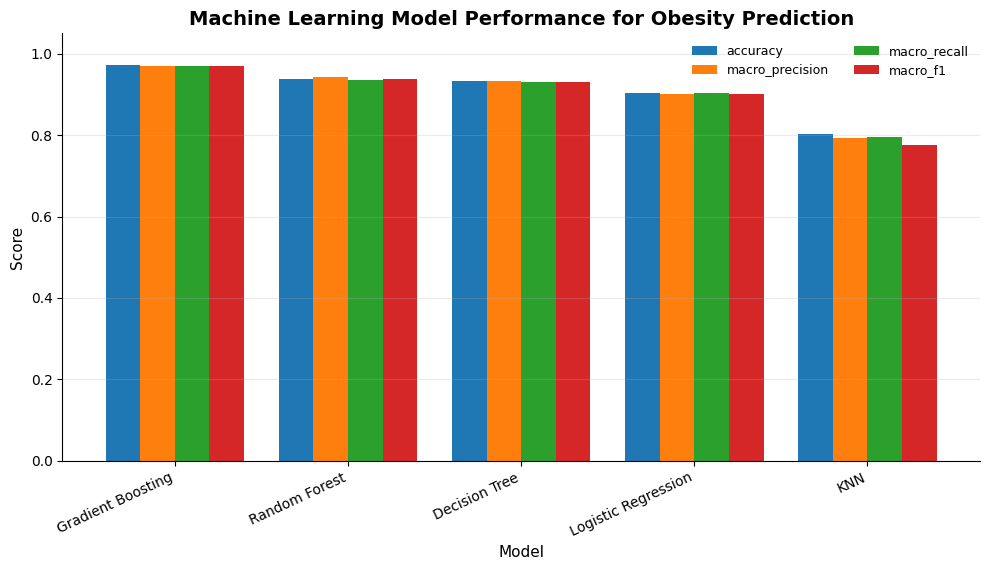

Saved figure: /kaggle/working/figures/RQ7_best_model_confusion_matrix.pdf


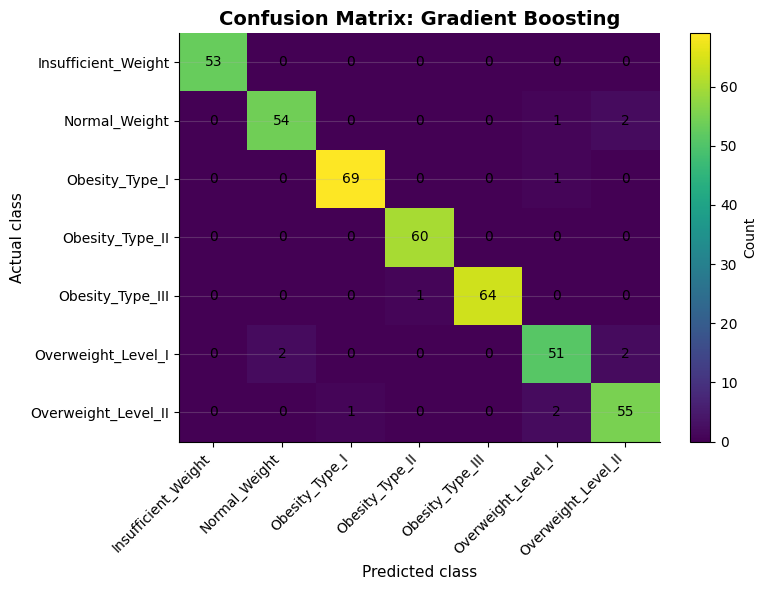


ANSWER TO RQ7
The best-performing model is Gradient Boosting, selected by highest macro-F1 score.
Best macro-F1: 0.970; accuracy: 0.971.
Macro-F1 is preferred because the target has multiple classes and class balance should be considered.


In [70]:

# RQ7: Best machine learning model for obesity prediction
# Variables: all predictors except NObeyesdad

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = df.drop(columns=['NObeyesdad', 'Obesity_Group', 'Obesity_Score'])
y = df['NObeyesdad']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocess_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)
preprocess_unscaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

models = {
    'Logistic Regression': (preprocess_scaled, LogisticRegression(max_iter=2000, class_weight='balanced')),
    'KNN': (preprocess_scaled, KNeighborsClassifier(n_neighbors=7)),
    'Decision Tree': (preprocess_unscaled, DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    'Random Forest': (preprocess_unscaled, RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')),
    'Gradient Boosting': (preprocess_unscaled, GradientBoostingClassifier(random_state=42, n_estimators=80))
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rows = []
predictions = {}
for name, (prep, clf) in models.items():
    pipe = Pipeline(steps=[('preprocess', prep), ('model', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

performance = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).round(5)
save_table(performance, 'RQ7_model_performance_comparison.csv')
display(performance)

best_model = performance.iloc[0]['model']
labels = sorted(y.unique())
cm = pd.DataFrame(confusion_matrix(y_test, predictions[best_model], labels=labels), index=[f'Actual: {l}' for l in labels], columns=[f'Pred: {l}' for l in labels])
cm_out = cm.reset_index().rename(columns={'index':'actual_class'})
save_table(cm_out, 'RQ7_best_model_confusion_matrix.csv')
display(cm)

# Figure: grouped bar chart for model metrics
fig_df = performance.set_index('model')[['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']]
ax = fig_df.plot(kind='bar', figsize=(10, 5.8), width=0.8)
style_plot('Machine Learning Model Performance for Obesity Prediction', 'Model', 'Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha='right')
plt.legend(frameon=False, fontsize=9, ncol=2)
save_figure('RQ7_model_performance_comparison.pdf')

# Extra figure: confusion matrix for best model
plt.figure(figsize=(8, 6))
plt.imshow(cm.values, aspect='auto')
plt.colorbar(label='Count')
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
plt.yticks(np.arange(len(labels)), labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm.values[i, j], ha='center', va='center')
style_plot(f'Confusion Matrix: {best_model}', 'Predicted class', 'Actual class')
save_figure('RQ7_best_model_confusion_matrix.pdf')

print('\nANSWER TO RQ7')
print(f"The best-performing model is {best_model}, selected by highest macro-F1 score.")
print(f"Best macro-F1: {performance.iloc[0]['macro_f1']:.3f}; accuracy: {performance.iloc[0]['accuracy']:.3f}.")
print('Macro-F1 is preferred because the target has multiple classes and class balance should be considered.')
